# Week 6: Advanced Python Analysis
## Apple (AAPL) Historical Stock Price Analysis
**Gloria Ubah**

### Business Problem
Analyze five years of Apple stock data to identify trends, perform time-series analysis, engineer features, and generate actionable insights.

## Project Objectives
- Load and explore the dataset
- Clean and preprocess data
- Transform data with Pandas
- Perform time-series analysis
- Engineer meaningful features
- Visualize trends
- Generate insights and recommendations

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(12,6)

stock_price = pd.read_csv("AAPL_5Y.csv", skiprows=2)
stock_price.head()

,Date,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,2021-07-07,140.919861,141.231774,139.058082,139.915853,104911600
1,2021-07-08,139.623489,140.422778,137.118369,138.005397,105575500
2,2021-07-09,141.446243,141.972603,139.048347,139.145828,99890800
3,2021-07-12,140.851654,142.625710,140.364278,142.518486,76299700
4,2021-07-13,141.962875,143.736931,140.003629,140.393524,100827100


In [5]:
stock_price.columns = [
    "Date",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

stock_price.head()

,Date,Close,High,Low,Open,Volume
0,2021-07-07,140.919861,141.231774,139.058082,139.915853,104911600
1,2021-07-08,139.623489,140.422778,137.118369,138.005397,105575500
2,2021-07-09,141.446243,141.972603,139.048347,139.145828,99890800
3,2021-07-12,140.851654,142.625710,140.364278,142.518486,76299700
4,2021-07-13,141.962875,143.736931,140.003629,140.393524,100827100


## Data Understanding

In [6]:
print('Shape:',stock_price.shape)
display(stock_price.head())
display(stock_price.tail())
stock_price.info()
display(stock_price.describe())
print(stock_price.isnull().sum())
print('Duplicates:',stock_price.duplicated().sum())

Shape: (1255, 6)


,Date,Close,High,Low,Open,Volume
0,2021-07-07,140.919861,141.231774,139.058082,139.915853,104911600
1,2021-07-08,139.623489,140.422778,137.118369,138.005397,105575500
2,2021-07-09,141.446243,141.972603,139.048347,139.145828,99890800
3,2021-07-12,140.851654,142.625710,140.364278,142.518486,76299700
4,2021-07-13,141.962875,143.736931,140.003629,140.393524,100827100


,Date,Close,High,Low,Open,Volume
1250,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
1251,2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
1252,2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800
1253,2026-07-06,312.660004,314.200012,307.000000,307.359985,53546100
1254,2026-07-07,312.260010,315.480011,310.149994,315.290009,24845010


<class 'pandas.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1255 non-null   str    
 1   Close   1255 non-null   float64
 2   High    1255 non-null   float64
 3   Low     1255 non-null   float64
 4   Open    1255 non-null   float64
 5   Volume  1255 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 59.0 KB


,Close,High,Low,Open,Volume
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,194.216555,196.159408,192.110387,194.023567,6.523417e+07
std,45.114087,45.498188,44.739906,45.102234,2.872870e+07
min,122.933540,125.637646,122.097738,123.907056,1.791060e+07
25%,156.775360,159.312481,154.972371,156.915007,4.575730e+07
50%,182.737045,184.481816,181.239159,182.955118,5.715700e+07
75%,226.743614,228.770710,224.733843,226.951390,7.732030e+07
max,315.200012,317.399994,310.149994,315.290009,3.186799e+08


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Duplicates: 0


## Data Cleaning

In [7]:
stock_price['Date']=pd.to_datetime(stock_price['Date'])
stock_price=stock_price.sort_values('Date').drop_duplicates().ffill().reset_index(drop=True)
stock_price.head()

,Date,Close,High,Low,Open,Volume
0,2021-07-07,140.919861,141.231774,139.058082,139.915853,104911600
1,2021-07-08,139.623489,140.422778,137.118369,138.005397,105575500
2,2021-07-09,141.446243,141.972603,139.048347,139.145828,99890800
3,2021-07-12,140.851654,142.625710,140.364278,142.518486,76299700
4,2021-07-13,141.962875,143.736931,140.003629,140.393524,100827100


## Data Transformation & Feature Engineering

In [9]:
stock_price['Daily Price Change']=stock_price['Close']-stock_price['Open']
stock_price['Percentage Change']=((stock_price['Close']-stock_price['Open'])/stock_price['Open'])*100
stock_price['Daily Return']=stock_price['Close'].pct_change()*100
stock_price['MA_7']=stock_price['Close'].rolling(7).mean()
stock_price['MA_30']=stock_price['Close'].rolling(30).mean()
stock_price['Volatility']=stock_price['Daily Return'].rolling(30).std()
stock_price['High-Low Difference']=stock_price['High']-stock_price['Low']
stock_price['Month']=stock_price['Date'].dt.month_name()
stock_price['Month_No']=stock_price['Date'].dt.month
stock_price['Quarter']=stock_price['Date'].dt.quarter
stock_price['Year']=stock_price['Date'].dt.year
stock_price.head()

,Date,Close,High,Low,Open,Volume,Daily Price Change,Percentage Change,Daily Return,MA_7,MA_30,Volatility,High-Low Difference,Month,Month_No,Quarter,Year
0,2021-07-07,140.919861,141.231774,139.058082,139.915853,104911600,1.004008,0.717580,NaN,NaN,NaN,NaN,2.173692,July,7,3,2021
1,2021-07-08,139.623489,140.422778,137.118369,138.005397,105575500,1.618092,1.172485,-0.919935,NaN,NaN,NaN,3.304409,July,7,3,2021
2,2021-07-09,141.446243,141.972603,139.048347,139.145828,99890800,2.300415,1.653240,1.305478,NaN,NaN,NaN,2.924256,July,7,3,2021
3,2021-07-12,140.851654,142.625710,140.364278,142.518486,76299700,-1.666832,-1.169555,-0.420364,NaN,NaN,NaN,2.261432,July,7,3,2021
4,2021-07-13,141.962875,143.736931,140.003629,140.393524,100827100,1.569351,1.117823,0.788930,NaN,NaN,NaN,3.733302,July,7,3,2021


## Time-Series Analysis

In [10]:
monthly=stock_price.groupby(['Year','Month_No'])['Close'].mean().reset_index()
yearly=stock_price.groupby('Year')['Close'].mean().reset_index()
monthly.head(), yearly

(   Year  Month_No       Close
 0  2021         7  142.350605
 1  2021         8  144.613965
 2  2021         9  144.778333
 3  2021        10  142.101189
 4  2021        11  150.765305,
    Year       Close
 0  2021  149.337074
 1  2022  151.805451
 2  2023  170.194611
 3  2024  205.457395
 4  2025  231.349892
 5  2026  274.095155)

## Visualizations

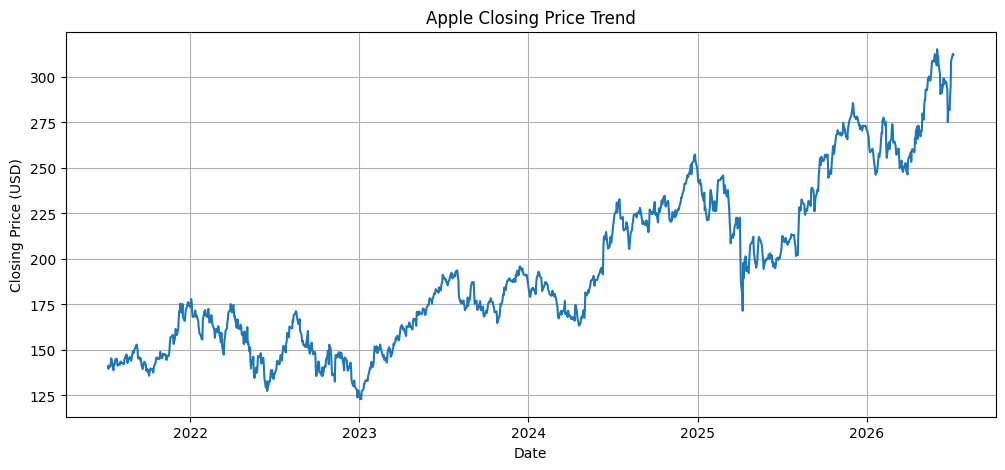

In [12]:
plt.figure(figsize=(12,5))
plt.plot(stock_price['Date'], stock_price['Close'])
plt.title('Apple Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.show()

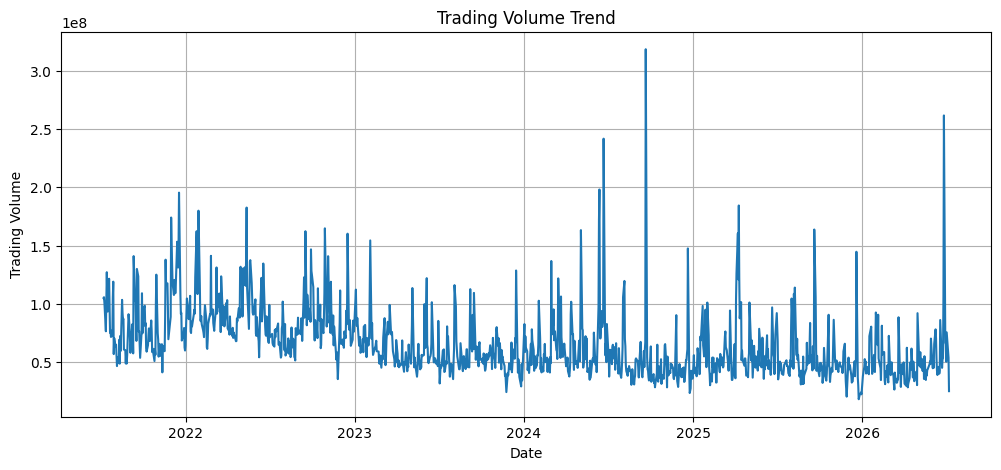

In [13]:
plt.figure(figsize=(12,5))
plt.plot(stock_price['Date'], stock_price['Volume'])
plt.title('Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.grid(True)
plt.show()

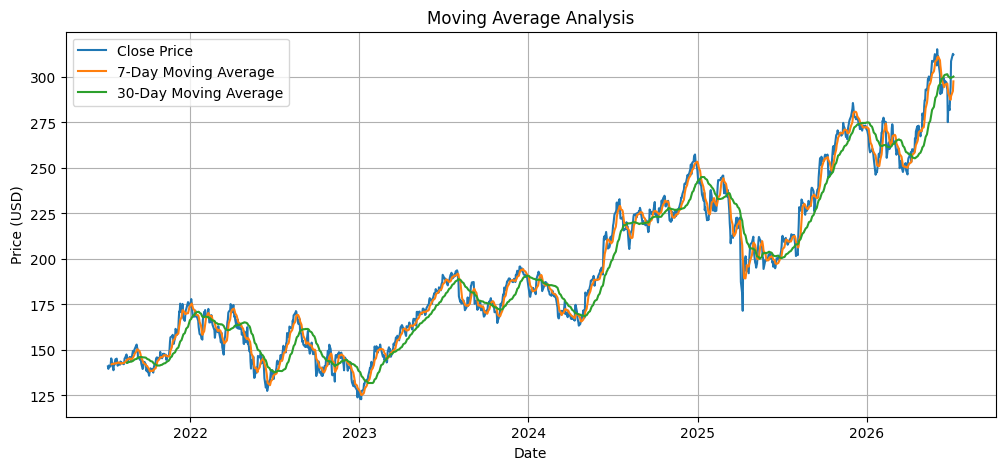

In [14]:
plt.figure(figsize=(12,5))
plt.plot(stock_price['Date'], stock_price['Close'], label='Close Price')
plt.plot(stock_price['Date'], stock_price['MA_7'], label='7-Day Moving Average')
plt.plot(stock_price['Date'], stock_price['MA_30'], label='30-Day Moving Average')

plt.title('Moving Average Analysis')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

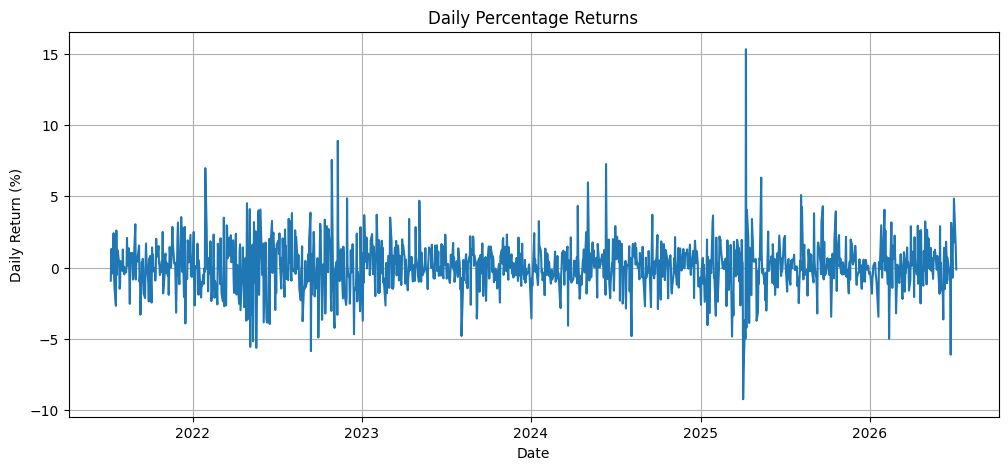

In [15]:
plt.figure(figsize=(12,5))
plt.plot(stock_price['Date'], stock_price['Daily Return'])
plt.title('Daily Percentage Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True)
plt.show()

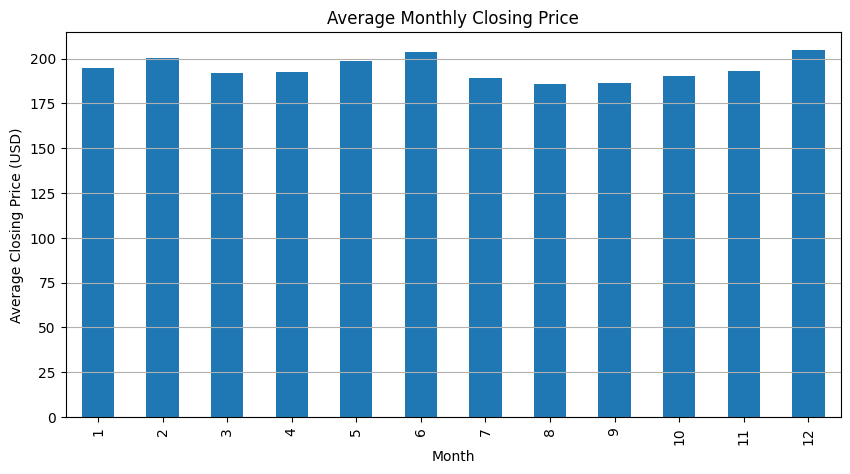

In [18]:
monthly_plot = stock_price.groupby('Month_No')['Close'].mean()

monthly_plot.plot(kind='bar', figsize=(10,5))
plt.title('Average Monthly Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Closing Price (USD)')
plt.grid(axis='y')
plt.show()

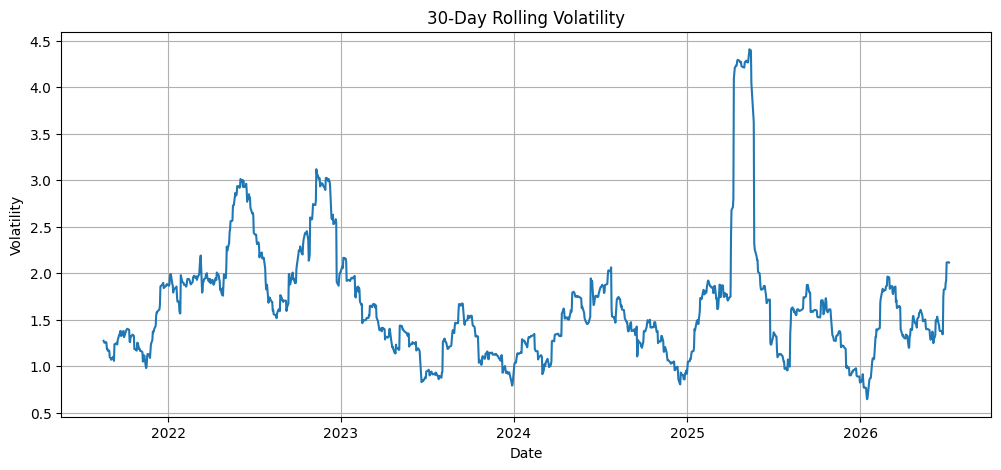

In [19]:
plt.figure(figsize=(12,5))
plt.plot(stock_price['Date'], stock_price['Volatility'])
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

# Key Findings

1. Apple's closing stock price showed a strong upward trend over the five-year period despite short-term market fluctuations.

2. Trading volume experienced significant spikes during major market events, indicating increased investor activity.

3. The 7-day moving average closely tracked daily prices, while the 30-day moving average provided a smoother long-term trend.

4. Daily returns fluctuated around zero, showing that gains and losses occurred frequently but generally balanced over time.

5. Average monthly closing prices revealed seasonal variations, with certain months consistently recording higher prices.

6. Rolling volatility increased during periods of market uncertainty, highlighting higher investment risk during those periods.

# Recommendations

1. Long-term investors should focus on the overall upward trend in Apple's stock rather than short-term price fluctuations.

2. Investors should monitor moving averages to identify potential buying and selling opportunities.

3. Periods of high volatility should be approached with caution, as they indicate increased market uncertainty and investment risk.

4. Trading volume should be analyzed alongside price movements, as unusual spikes may signal important market events or changes in investor sentiment.

5. Combining technical indicators such as moving averages, daily returns, and volatility with fundamental analysis can improve investment decision-making.

6. Future analysis could include comparisons with other technology companies, stock price forecasting using machine learning models, and the impact of major economic events on Apple's stock performance.

# Conclusion

This analysis demonstrates how Python and Pandas can be used to transform raw stock market data into meaningful business insights. Through data cleaning, feature engineering, time-series analysis, and visualization, important trends in Apple's stock performance were identified. The use of moving averages and volatility measures provides valuable information for investors and financial analysts when making informed investment decisions.